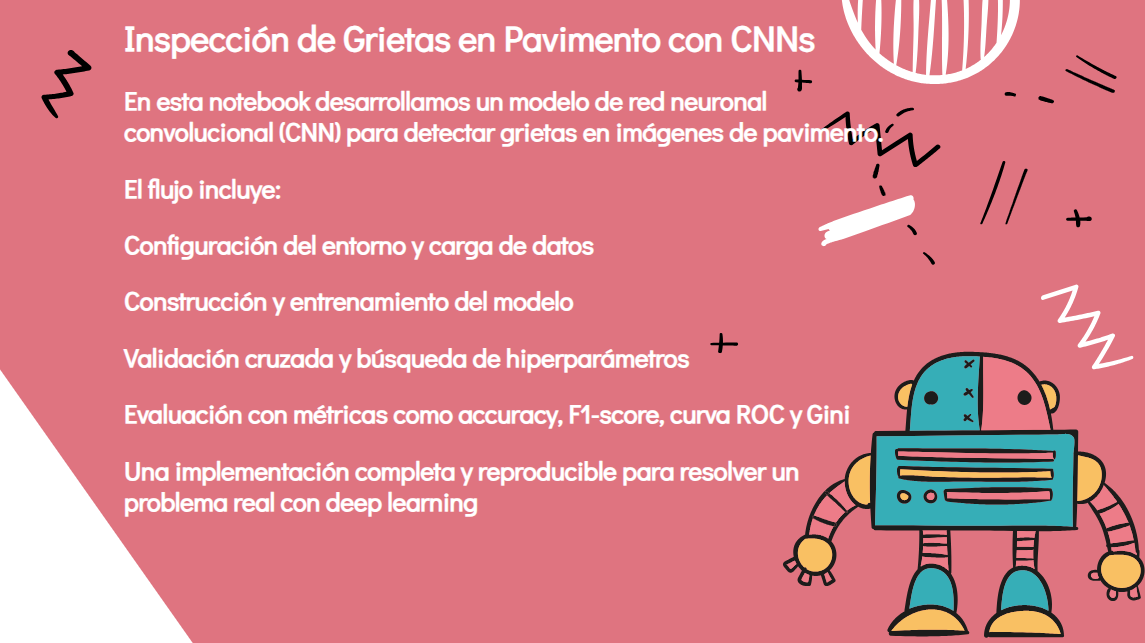

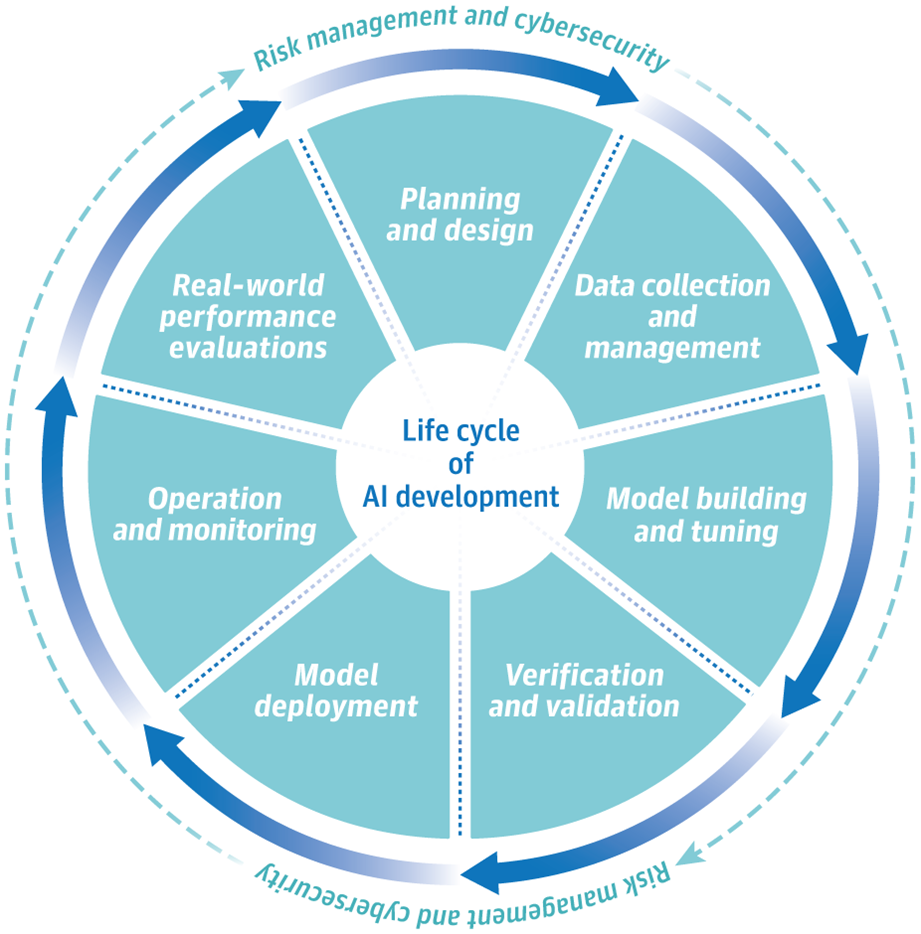

[Fuente](https://jamanetwork.com/journals/jama/article-abstract/2825146#jsc240014r12)

# Infraestructura

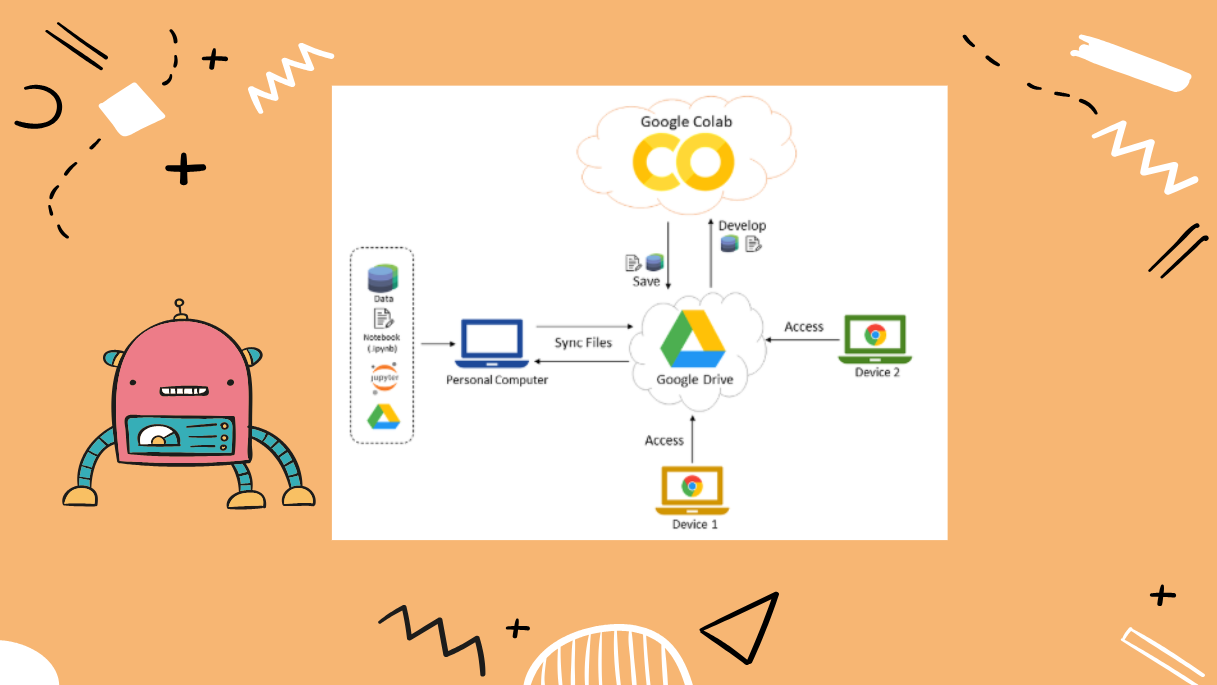

In [ ]:
# Instalación de paquetes necesarios (sin tensorflow-addons)
!pip install -U visualkeras --quiet
!pip install cvlib --quiet
!pip install kagglehub --quiet
# Verificación de GPU
!nvidia-smi

# Imports esenciales
import os
import warnings
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.preprocessing.image import load_img

import visualkeras

# Configuracion general
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Parametros globales
image_size = 240
epochs = 15
BATCH_SIZE = 32


Tue Jul 22 03:46:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Carga de datos y creacion del DATASET

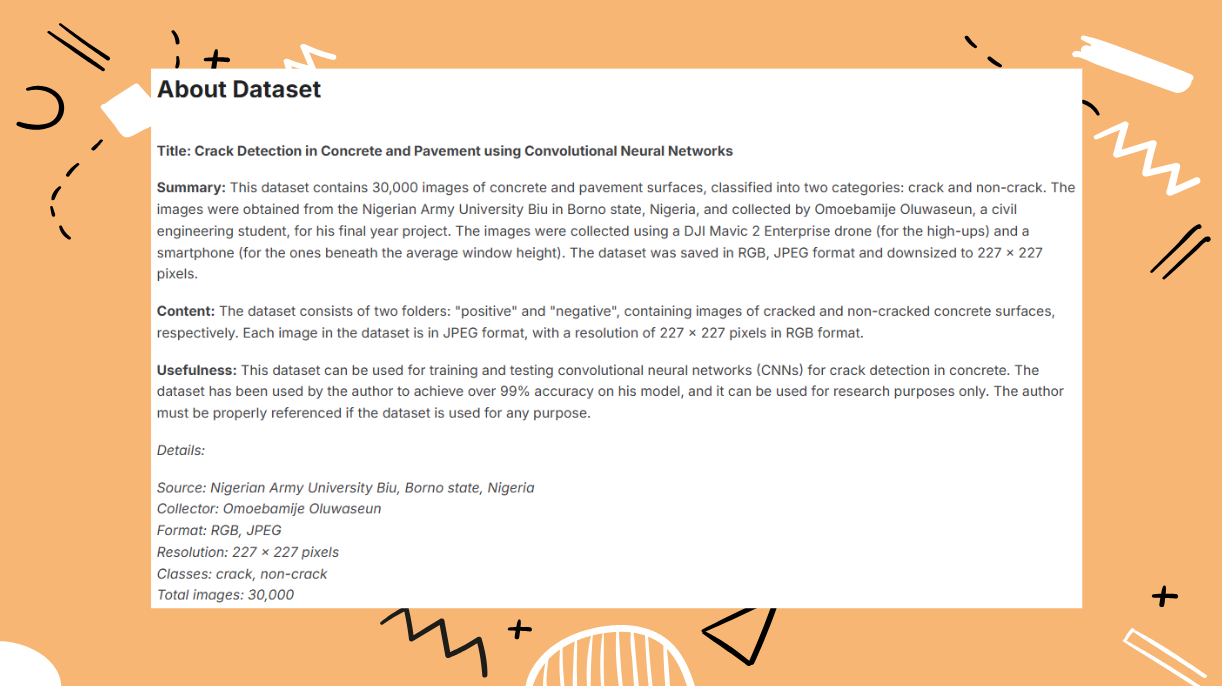

[Concrete & Pavement Crack Dataset](https://www.kaggle.com/datasets/oluwaseunad/concrete-and-pavement-crack-images)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oluwaseunad/concrete-and-pavement-crack-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/concrete-and-pavement-crack-images


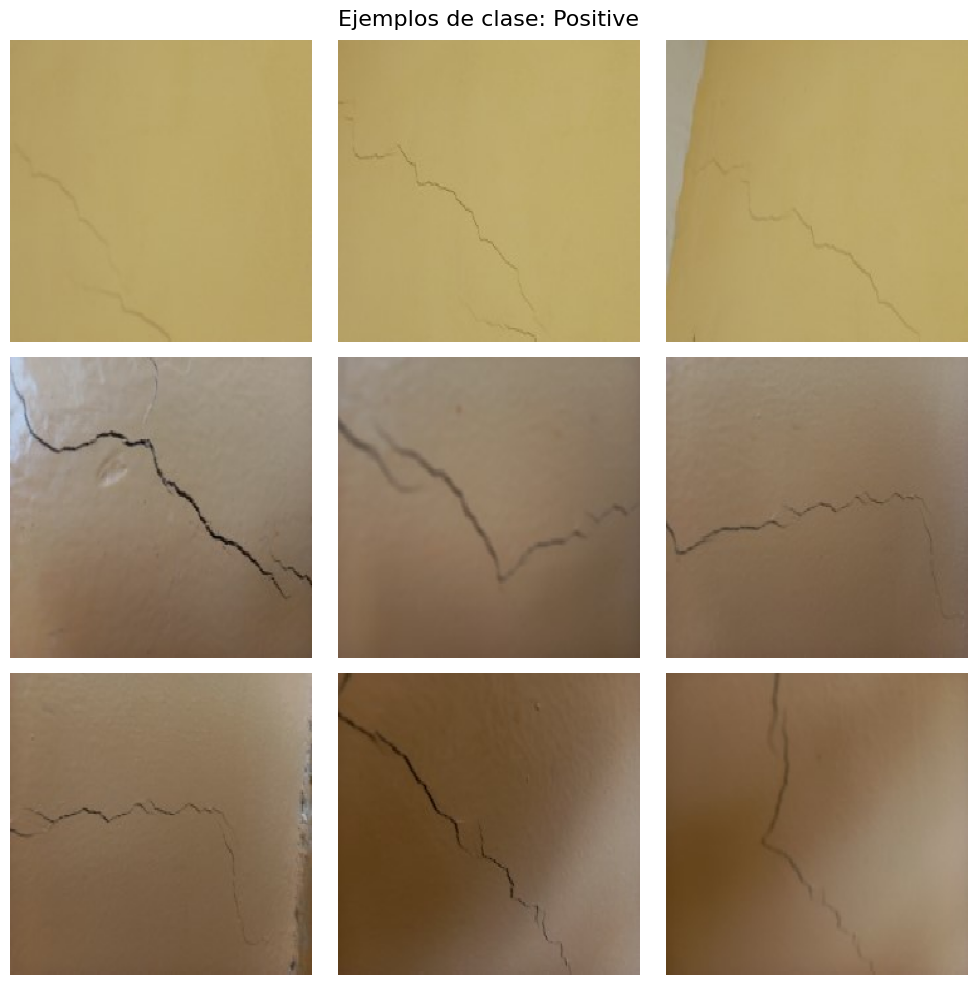

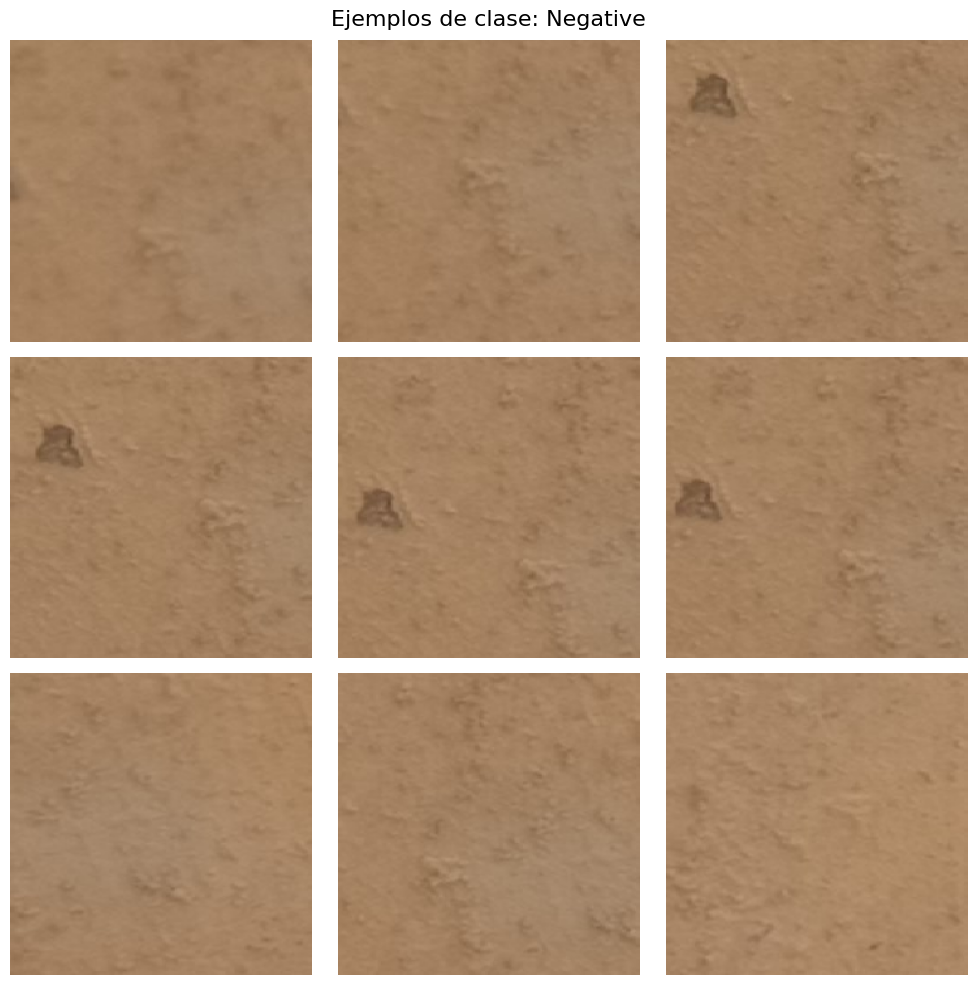

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def show_sample_images(folder_path, class_names, img_size=240, samples=9):
    for class_name in class_names:
        image_dir = os.path.join(folder_path, class_name)
        image_paths = sorted(os.listdir(image_dir))[:samples]

        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        fig.suptitle(f"Ejemplos de clase: {class_name}", fontsize=16)

        for ax, img_name in zip(axes.flat, image_paths):
            img_path = os.path.join(image_dir, img_name)
            img = load_img(img_path, target_size=(img_size, img_size))
            ax.imshow(img)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

# Mostrar ejemplos
show_sample_images(path, ['Positive', 'Negative'], img_size=image_size)


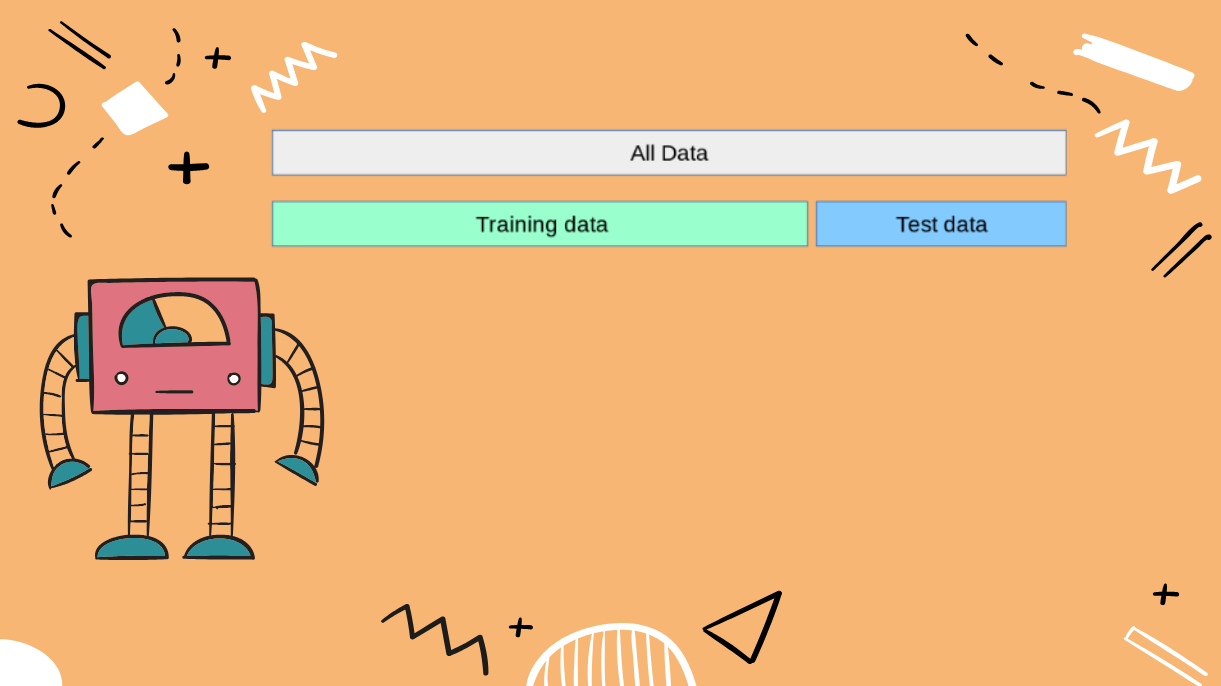

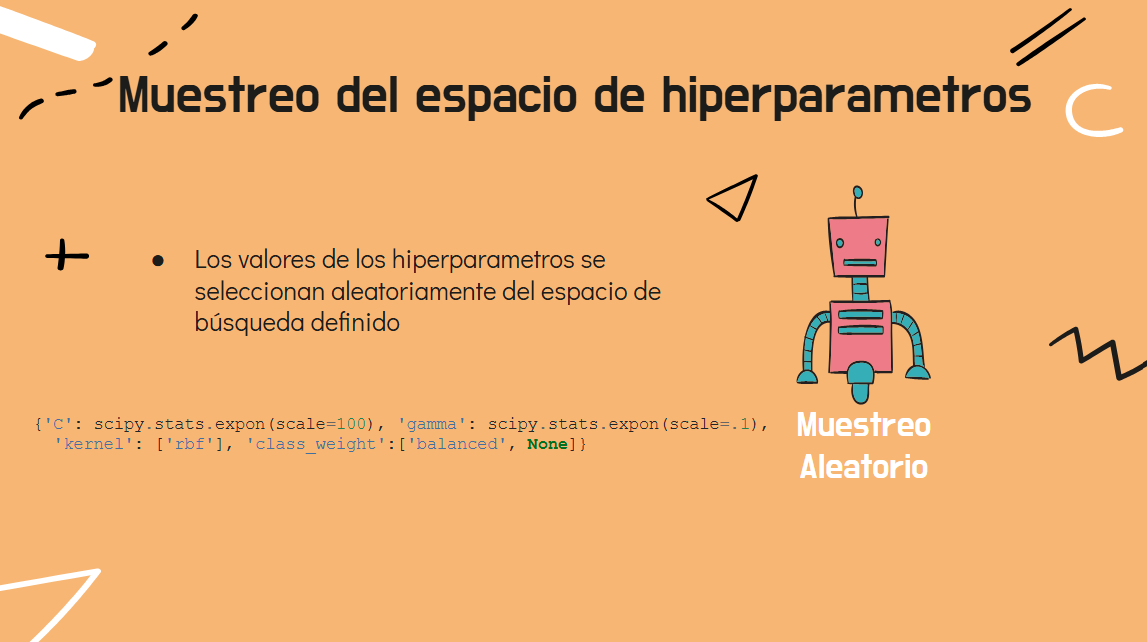

In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import gc  # garbage collector para liberar memoria

def load_images_from_folder(folder_path, img_size=160, max_images_per_class=None):
    dataset = []
    labels = []
    classes = ['Negative', 'Positive']

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)
        image_files = sorted(os.listdir(class_path))

        # Limitar la cantidad de imágenes por clase si se especifica
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue  # ignorar archivos corruptos
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            dataset.append(img)
            labels.append(label)

    # Convertir a float16 para reducir a la mitad el consumo de RAM
    dataset = np.array(dataset, dtype=np.float16) / 255.0
    labels = np.array(labels)

    return dataset, labels

# === Configuración de carga ===
image_size = 160  # más chico que 240 para menos RAM
MAX_IMAGES = 3000  # o ajustá según tu límite de memoria

# === Cargar y procesar imágenes ===
dataset, labels = load_images_from_folder(path, img_size=image_size, max_images_per_class=MAX_IMAGES)



# Creacion del modelo

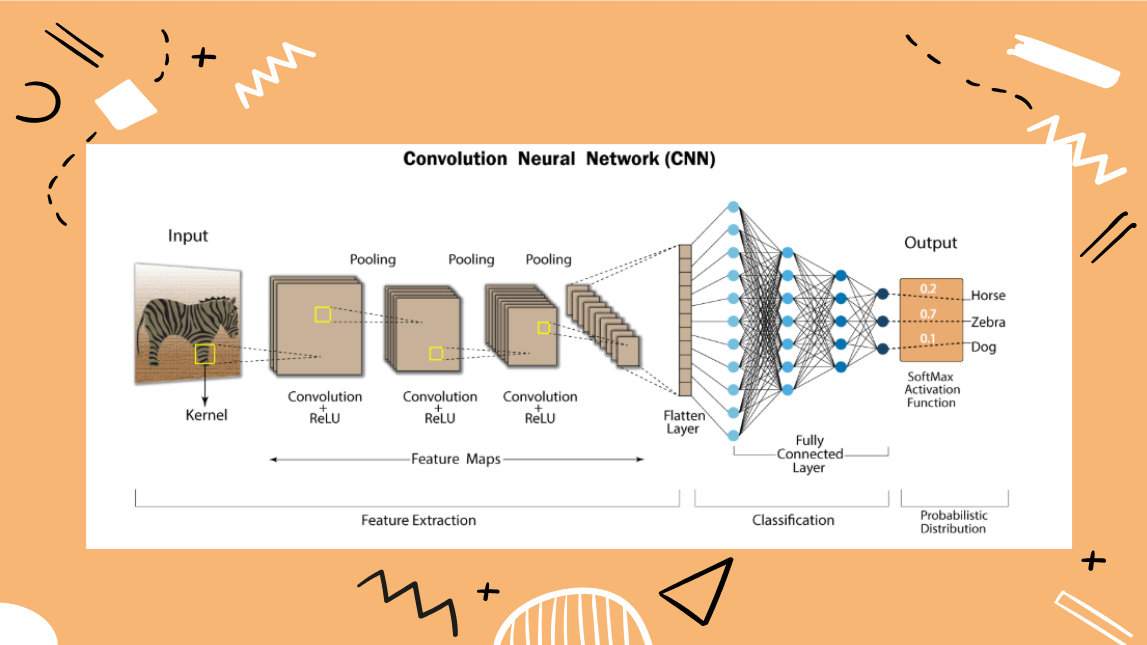

In [ ]:
from tensorflow.keras import layers, models, regularizers

# Definir modelo CNN
cnn_model = models.Sequential([
    layers.Input(shape=(image_size, image_size, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # clasificación binaria

])

# Compilar modelo
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,001 (25.36 MB)

 Trainable params: 6,647,553 (25.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Entrenamiento

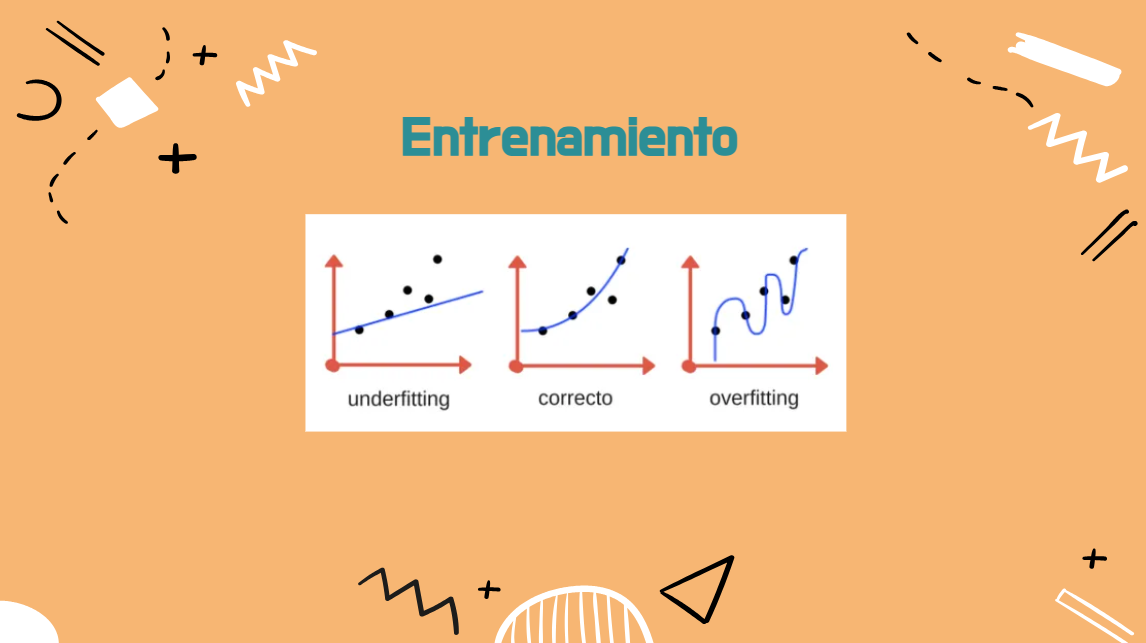

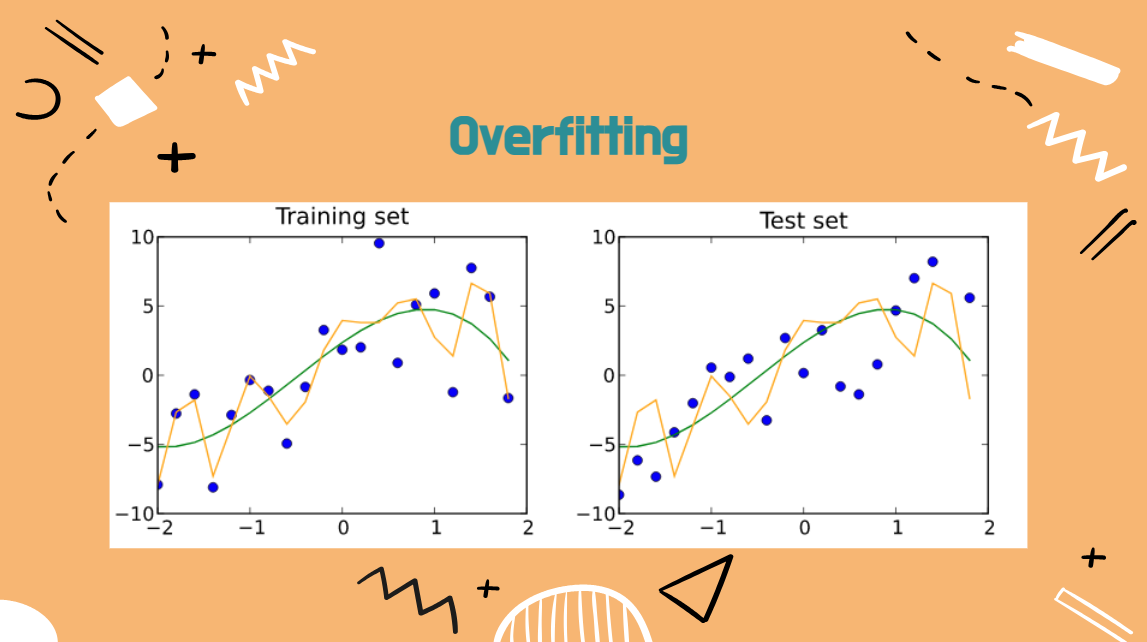

In [ ]:
from sklearn.model_selection import train_test_split

# Normalización: escala los valores de píxeles de [0, 255] a [0, 1]
dataset = dataset.astype("float32") / 255.0

# División en conjunto de entrenamiento y prueba (80/20)
x_train, x_test, y_train, y_test = train_test_split(
    dataset, labels,
    test_size=0.2,
    stratify=labels,  # mantiene proporción entre clases
    random_state=42
)

# Mostrar formas
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape:  {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

x_train shape: (4800, 160, 160, 3)
x_test shape:  (1200, 160, 160, 3)
y_train shape: (4800,)
y_test shape:  (1200,)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras import layers, models, regularizers
import numpy as np

acc_scores = []
f1_scores = []
histories = []

history = cnn_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                  epochs=4,
                  batch_size=32,
                  verbose=1)

histories.append(history)
y_val_pred_probs = cnn_model.predict(x_test)
y_val_pred = (y_val_pred_probs > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_val_pred)
f1 = f1_score(y_test, y_val_pred)

acc_scores.append(acc)
f1_scores.append(f1)

print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

Epoch 1/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9763 - loss: 0.3178 - val_accuracy: 0.5000 - val_loss: 31.0597
Epoch 2/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9721 - loss: 0.2883 - val_accuracy: 0.5000 - val_loss: 36.2427
Epoch 3/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9771 - loss: 0.3175 - val_accuracy: 0.9675 - val_loss: 0.3457
Epoch 4/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9734 - loss: 0.3380 - val_accuracy: 0.9567 - val_loss: 0.3514
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.9567, F1 Score: 0.9577


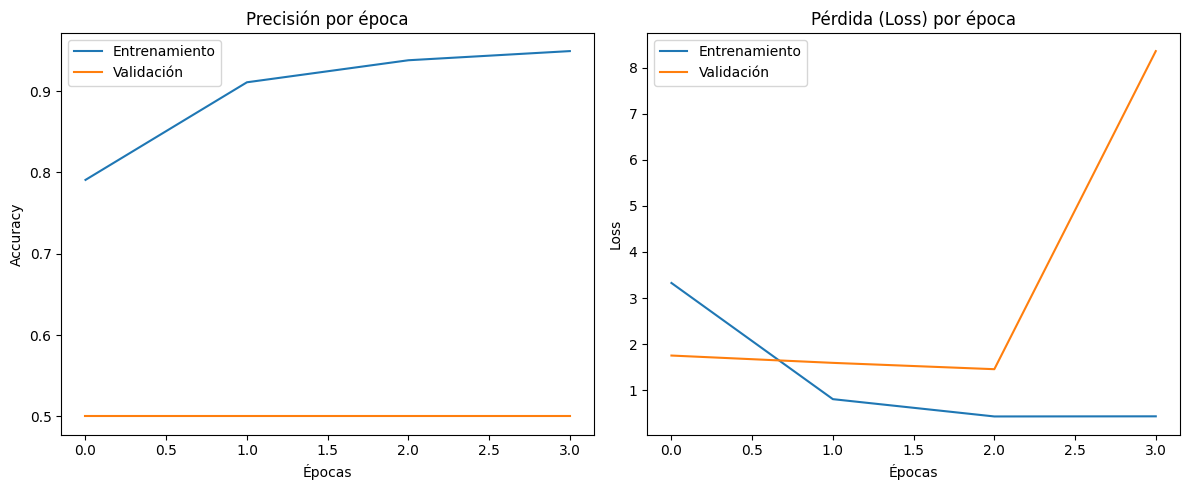

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 5))

    # Precisión
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Entrenamiento')
    plt.plot(val_acc, label='Validación')
    plt.title('Precisión por época')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    # Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Entrenamiento')
    plt.plot(val_loss, label='Validación')
    plt.title('Pérdida (Loss) por época')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Mostrar gráficos
plot_training_history(history)

# Validacion Cruzada

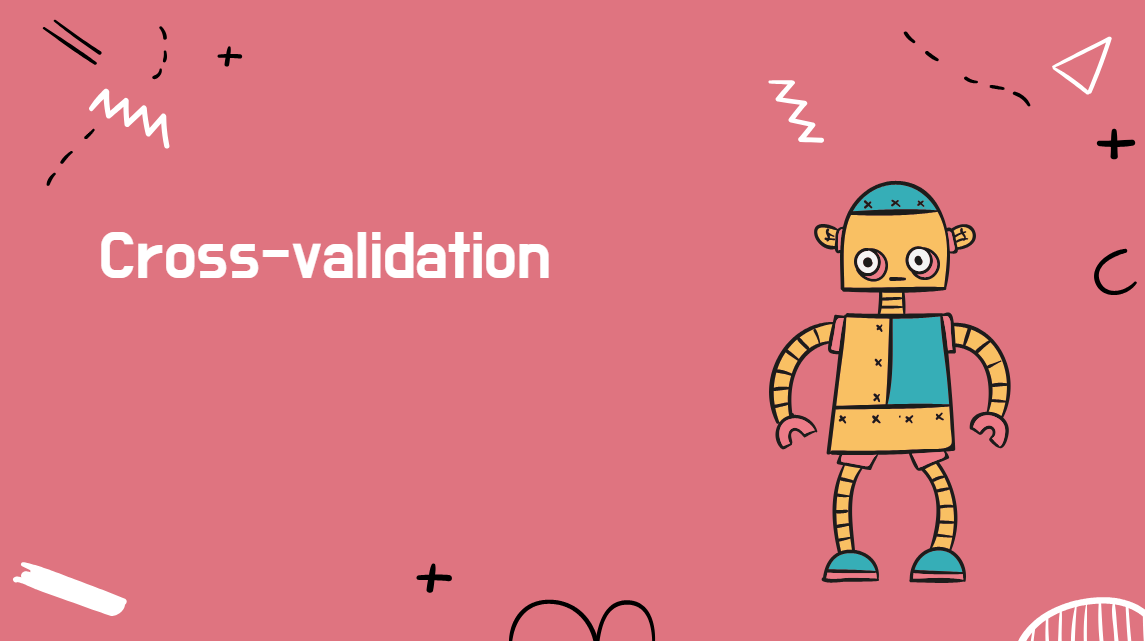

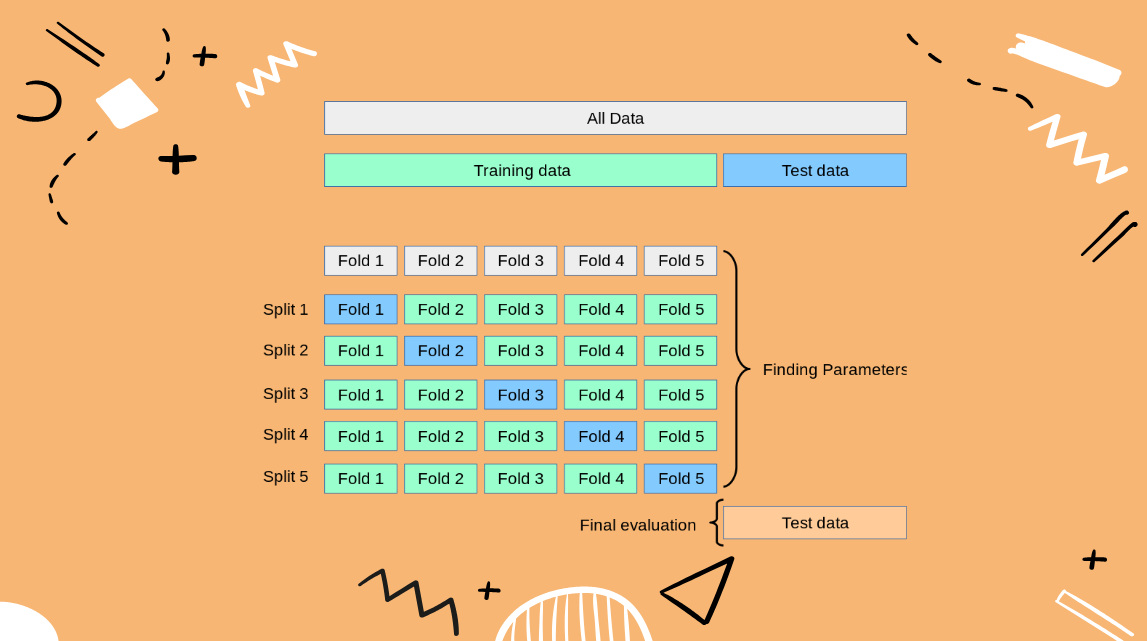

In [ ]:
def run_crossval(dataset, labels, image_size, n_splits=4, epochs=3, batch_size=32,
                 dropout_rate=0.5, l2_strength=0.01, verbose=0):
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
    from tensorflow.keras import layers, models, regularizers
    import numpy as np

    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc_scores, f1_scores, roc_aucs, ginis = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset, labels)):
        x_train_fold, x_val_fold = dataset[train_idx], dataset[val_idx]
        y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]

        model = models.Sequential([
            layers.Input(shape=(image_size, image_size, 3)),
            layers.Conv2D(32, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Conv2D(128, 3, activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_strength)),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        model.fit(
            x_train_fold, y_train_fold,
            validation_data=(x_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose
        )

        y_val_pred_probs = model.predict(x_val_fold).flatten()
        y_val_pred = (y_val_pred_probs > 0.5).astype(int)

        acc = accuracy_score(y_val_fold, y_val_pred)
        f1 = f1_score(y_val_fold, y_val_pred)
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_pred_probs)
        roc_auc = auc(fpr, tpr)
        gini = 2 * roc_auc - 1

        acc_scores.append(acc)
        f1_scores.append(f1)
        roc_aucs.append(roc_auc)
        ginis.append(gini)

    return {
        "accuracy_mean": np.mean(acc_scores),
        "accuracy_std": np.std(acc_scores),
        "f1_mean": np.mean(f1_scores),
        "auc_mean": np.mean(roc_aucs),
        "gini_mean": np.mean(ginis)
    }


# Optimizacion de Hiperparametros

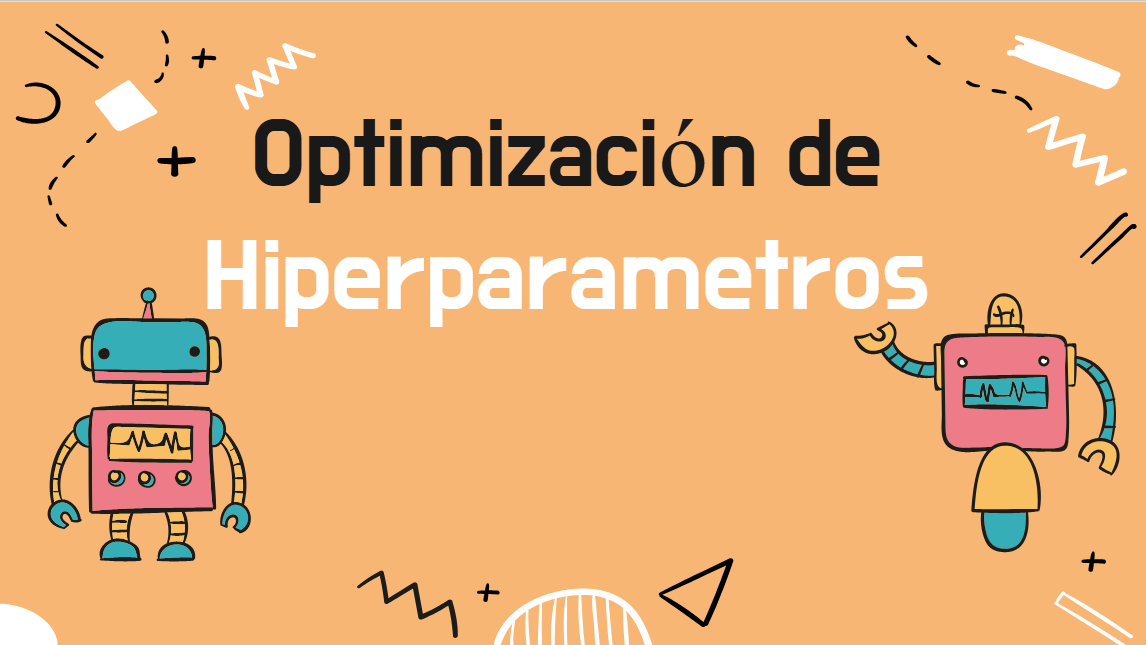

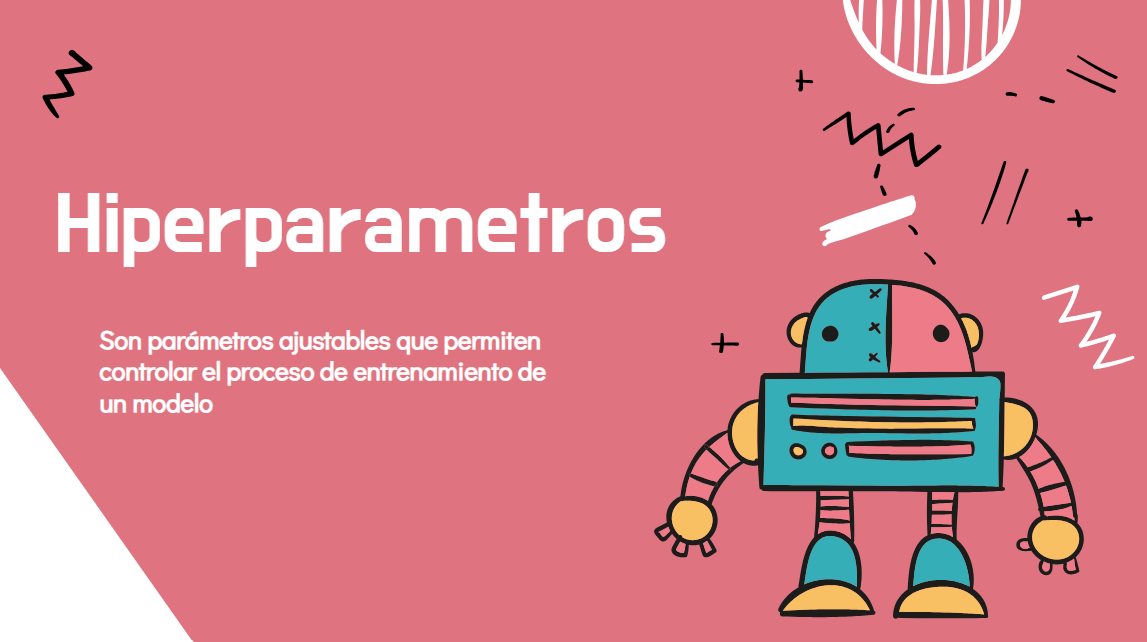

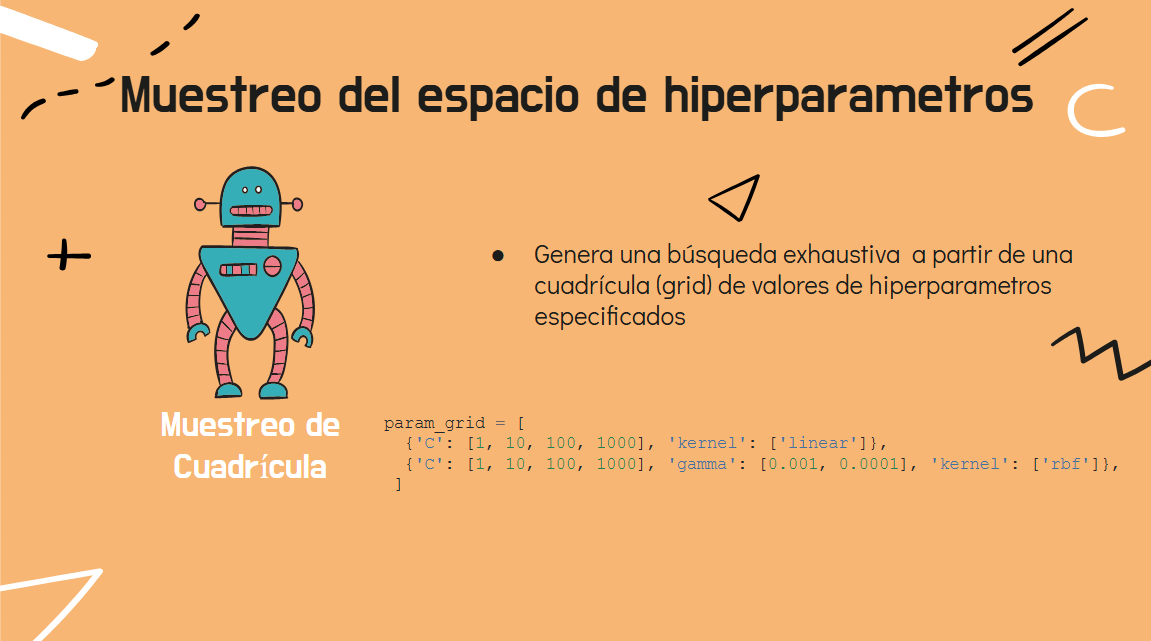

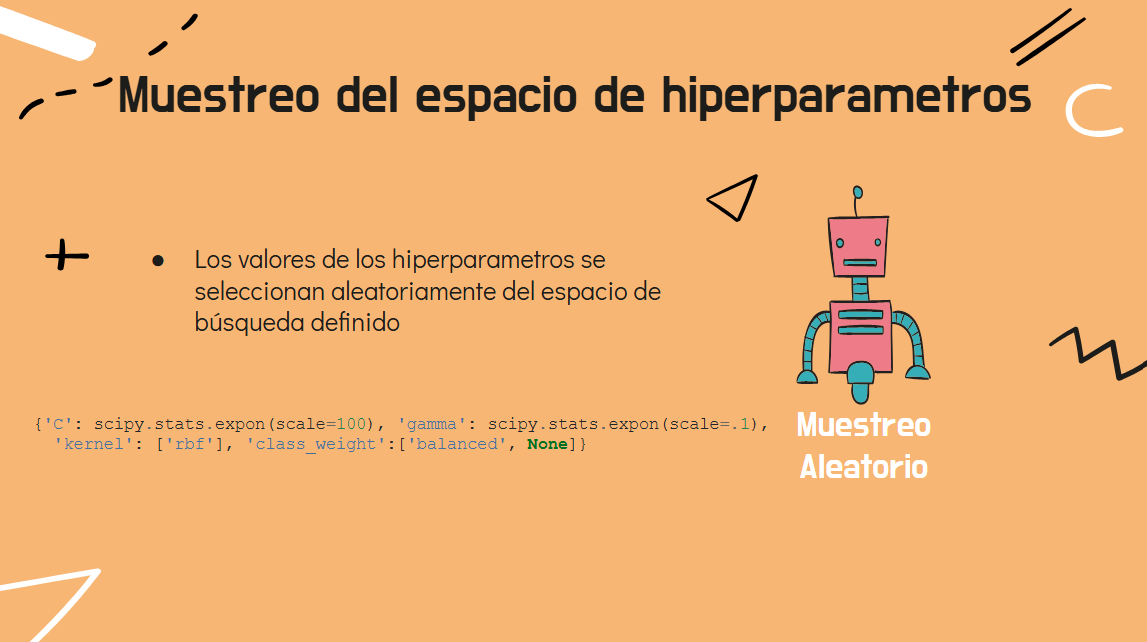

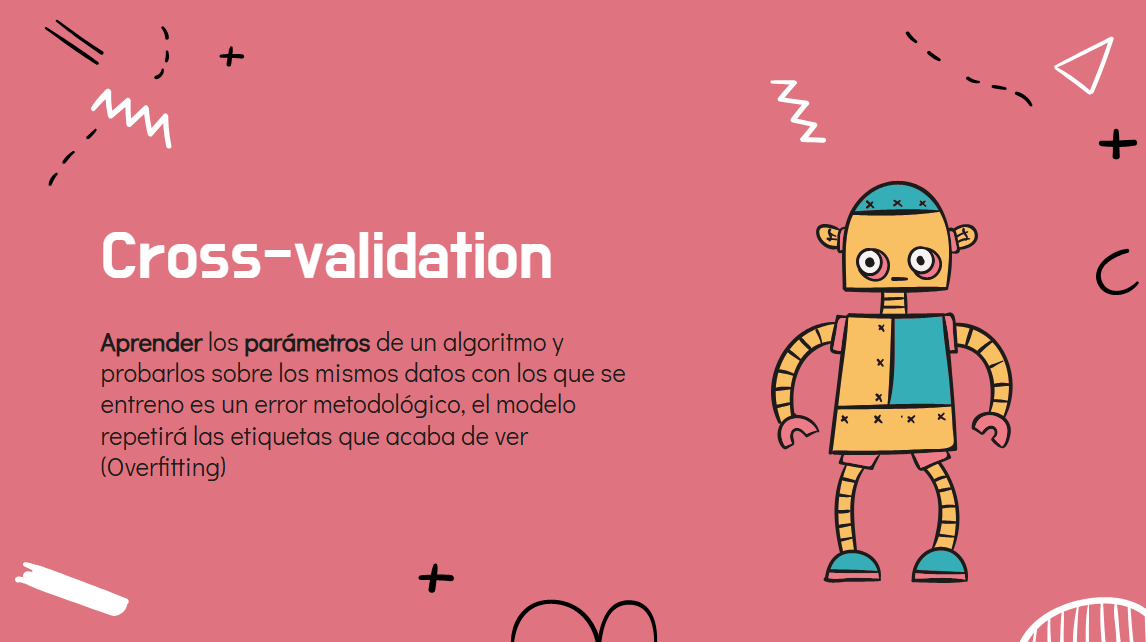

In [ ]:
param_grid = {
    "epochs": [1],
    "batch_size": [32, 64],
    "dropout_rate": [0.3, 0.5]
}

import itertools

results = []

for values in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), values))
    print(f"Evaluando: {params}")
    scores = run_crossval(
        dataset, labels, image_size,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        dropout_rate=params["dropout_rate"],
        verbose=0
    )
    results.append({**params, **scores})


Evaluando: {'epochs': 1, 'batch_size': 32, 'dropout_rate': 0.3}
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Evaluando: {'epochs': 1, 'batch_size': 32, 'dropout_rate': 0.5}
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Evaluando: {'epochs': 1, 'batch_size': 64, 'dropout_rate': 0.3}
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Evaluando: {'epochs': 1, 'batch_size': 64, 'dropout_rate': 0.5}
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("f1_mean", ascending=False)
df_results

,epochs,batch_size,dropout_rate,accuracy_mean,accuracy_std,f1_mean,auc_mean,gini_mean
1,1,32,0.5,0.5,0.0,0.333333,0.607422,0.214845
0,1,32,0.3,0.5,0.0,0.000000,0.599830,0.199660
2,1,64,0.3,0.5,0.0,0.000000,0.641805,0.283610
3,1,64,0.5,0.5,0.0,0.000000,0.610483,0.220966


# Metricas

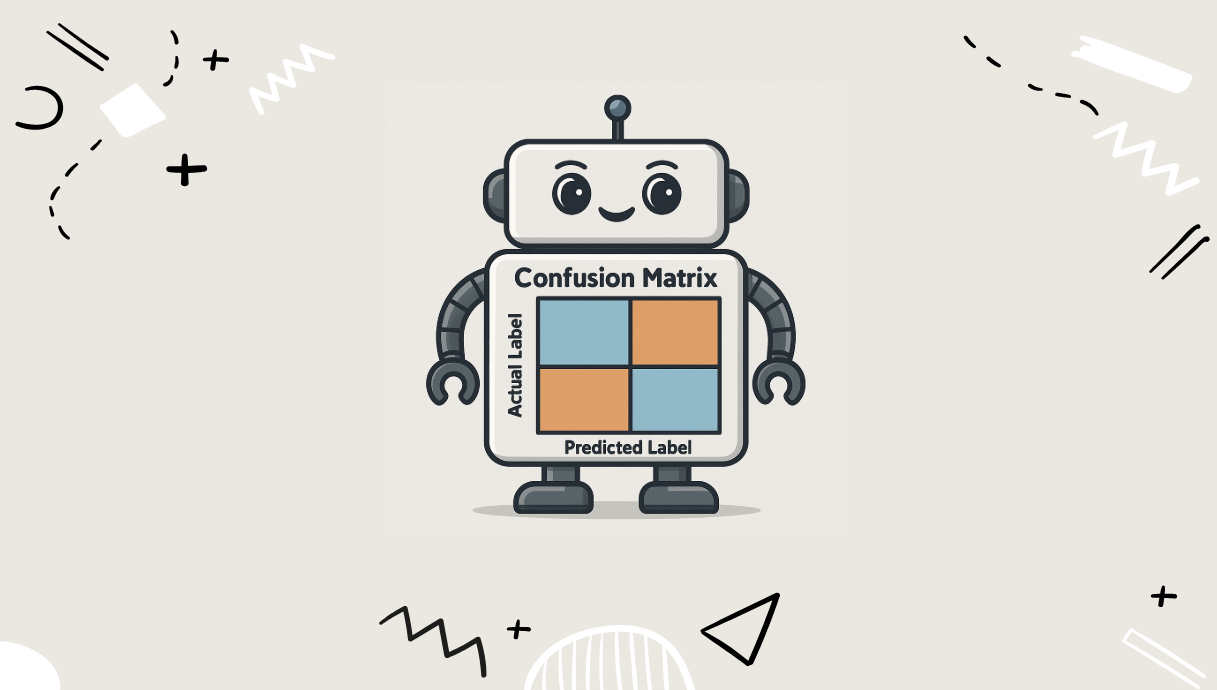

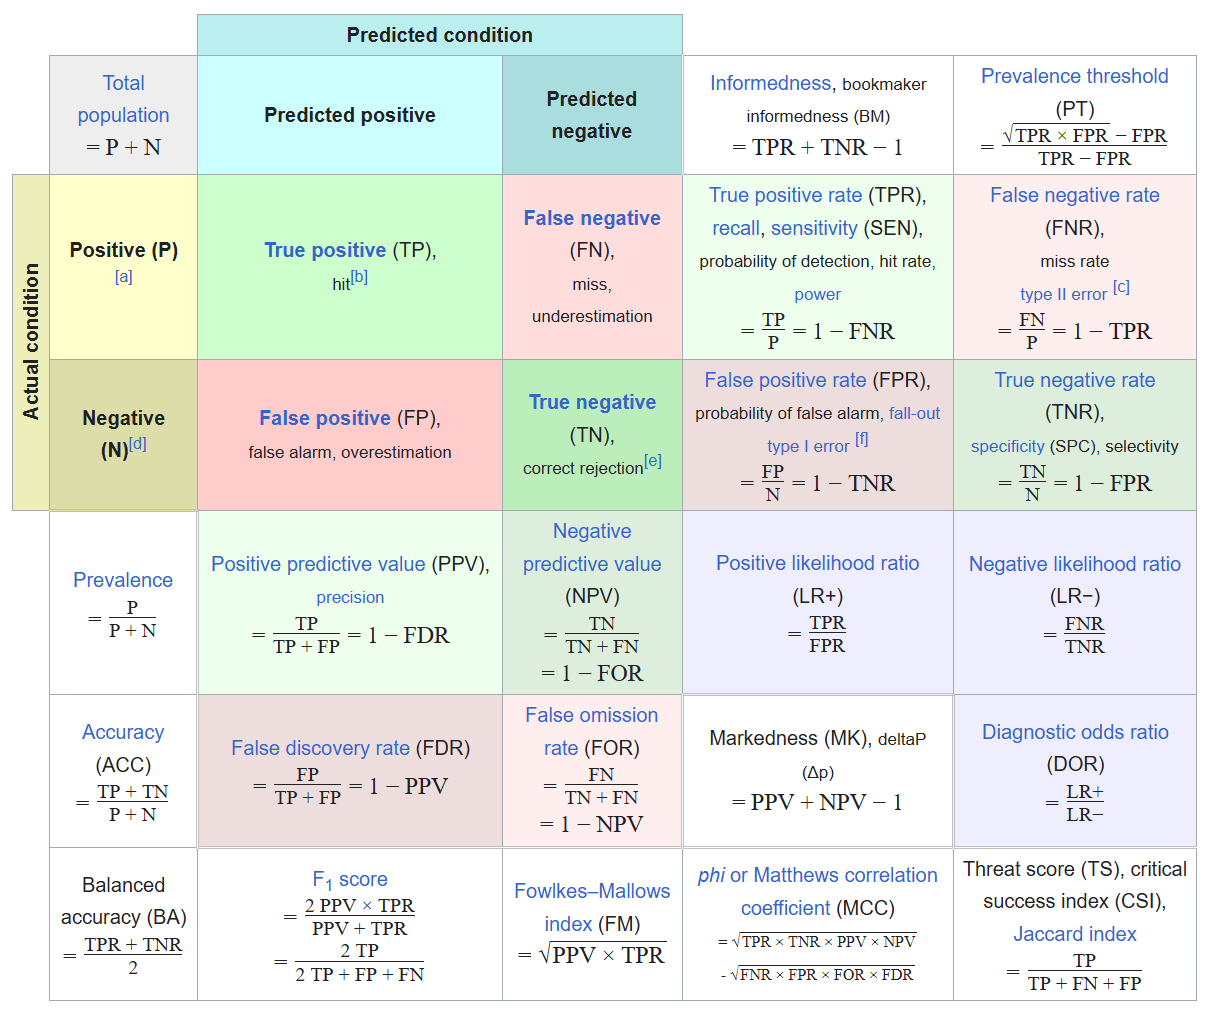

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== Reporte de Clasificación ===
              precision    recall  f1-score   support

    Negative       0.98      0.93      0.96       600
    Positive       0.94      0.98      0.96       600

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200

F1 Score: 0.9577


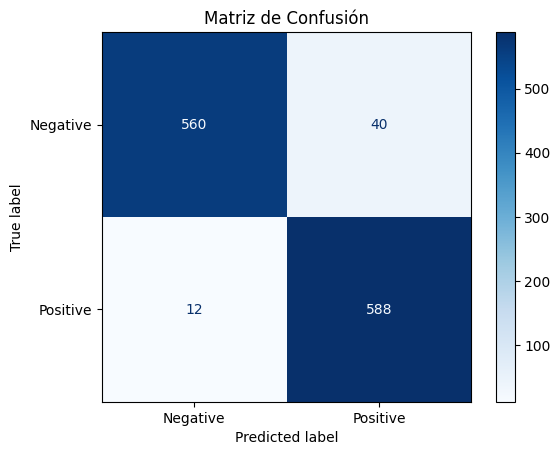

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Obtener predicciones (probabilidades entre 0 y 1)
y_pred_probs = cnn_model.predict(x_test)

# Convertir a etiquetas binarias (0 o 1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Imprimir métricas
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# F1 Score (resumen útil en clases balanceadas o desbalanceadas)
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
tp, fn, fp, tn = confusion_matrix(y_test, y_pred).ravel()
print("Number of true positives  (tp) = ",tp)
print("Number of true negatives  (tn) = ",tn)

print("Number of false positives (fp) = ",fp)
print("Number of false negatives (fn) = ",fn)

print("Precision                                          = tp / (tp + fp) =", tp / (tp + fp))
print("Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) =", tp / (tp + fn))
print("Specificity             (aka. true negative rate)  = tn / (tn + fp) =", tn / (tn + fp))
print("Fall out                (aka. false positive rate) = fp / (fp + tn) =", fp / (fp + tn))
print("Miss rate               (aka. false negative rate) = fn / (fn + tp) =", fn / (fn + tp))

Number of true positives  (tp) =  560
Number of true negatives  (tn) =  588
Number of false positives (fp) =  12
Number of false negatives (fn) =  40
Precision                                          = tp / (tp + fp) = 0.9790209790209791
Recall or 'sensitivity' (aka. true positive rate)  = tp / (tp + fn) = 0.9333333333333333
Specificity             (aka. true negative rate)  = tn / (tn + fp) = 0.98
Fall out                (aka. false positive rate) = fp / (fp + tn) = 0.02
Miss rate               (aka. false negative rate) = fn / (fn + tp) = 0.06666666666666667


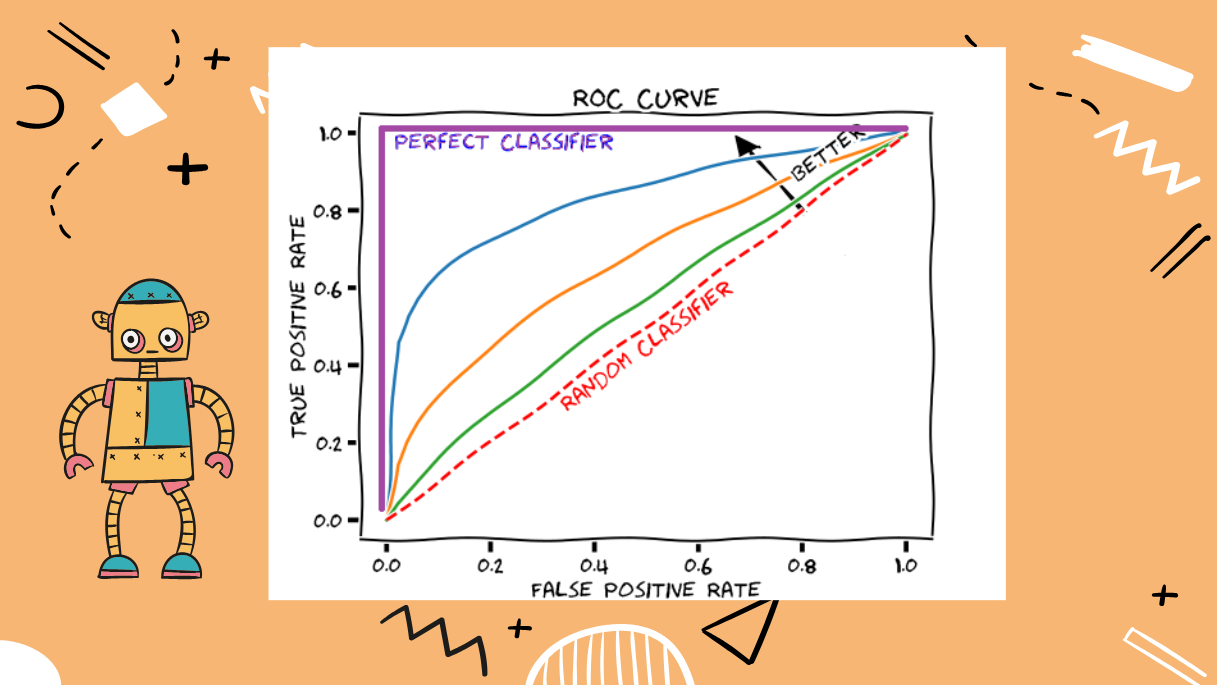

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_and_gini(y_true, y_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    gini = 2 * roc_auc - 1

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('FPR (Tasa de Falsos Positivos)')
    plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    print(f"AUC: {roc_auc:.4f}")
    print(f"Gini: {gini:.4f}")


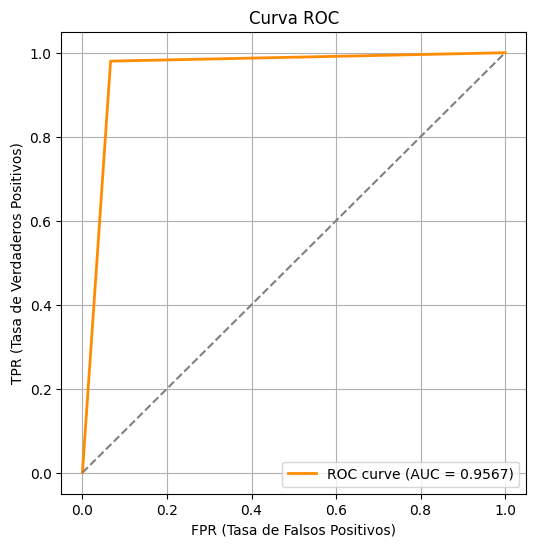

AUC: 0.9567
Gini: 0.9133


In [ ]:
plot_roc_and_gini(y_test, y_pred)